# File to run experiments with various hyperparameters

In [1]:
import pandas as pd
import numpy as np
import torch
import strats
import datetime
import os
import csv
import matplotlib.pyplot as plt
import seaborn as sns
import pickle



print(datetime.datetime.now())


Initializing package . . . 😘
2025-03-26 12:25:40.371646


# Prepare Data

### Functions

In [2]:
def process_static(static):
    # Treat only in-hospital death
    static.loc[static['hospital_expire_flag'] == 0, 'deathtime'] = None
    print(len(static[static['outtime'] + 1440 >= static['deathtime']]))
    static = static.loc[:,['hadm_id', 'deathtime']]
    static = static.rename(columns={'hadm_id': 'hadm_id', 'deathtime' : 'death_offset'})
    unique_static_ids = static['hadm_id'].unique()
    return static, unique_static_ids

def compute_trimmed_stats(values: pd.Series, low_pct: float, high_pct: float):
    """
    values: 해당 그룹의 value Series
    low_pct, high_pct: 잘라낼 분위수 (예: 0.01, 0.99)
    
    반환: (trimmed_mean, trimmed_std)
    """
    lower_bound = values.quantile(low_pct)
    upper_bound = values.quantile(high_pct)
    trimmed = values[(values >= lower_bound) & (values <= upper_bound)]
    return trimmed.mean(), trimmed.std()

def calculate_all_stats(df: pd.DataFrame):
    # 결과를 담을 리스트
    results = []

    # itemid별로 그룹화
    grouped = df.groupby('itemid')

    for item_id, group in grouped:
        vals = group['value']

        # 1) 전체(아웃라이어 제거 없음) 평균/표준편차
        orig_mean = vals.mean()
        orig_std  = vals.std()

        # 2) 상하위 1% 제거
        mean_1pct, std_1pct = compute_trimmed_stats(vals, 0.01, 0.99)

        # 3) 상하위 3% 제거
        mean_3pct, std_3pct = compute_trimmed_stats(vals, 0.03, 0.97)

        # 4) 상하위 5% 제거
        mean_5pct, std_5pct = compute_trimmed_stats(vals, 0.05, 0.95)

        # 결과 한 줄로 정리
        results.append({
            'itemid': item_id,
            'orig_mean': orig_mean,
            'orig_std': orig_std,
            'mean_1pct': mean_1pct,
            'std_1pct': std_1pct,
            'mean_3pct': mean_3pct,
            'std_3pct': std_3pct,
            'mean_5pct': mean_5pct,
            'std_5pct': std_5pct,
            'lower_1' : vals.quantile(0.01),
            'upper_1' : vals.quantile(0.99),
        })

    # 리스트를 DataFrame으로
    df_stats = pd.DataFrame(results)
    return df_stats

def find_cf_onset_for_patient(patient_df, map_itemids, lactate_itemids, c01_itemids):
    """
    환자 한 명(patient_df)에 대해
    offset 오름차순으로 보면서 "최초 CF 발생 시점"을 찾는다.

    - data columns: [hadm_id, offset, itemid, value]
    - return: float(cf_offset) or np.nan
    """
    # offset 기준으로 정렬
    patient_df = patient_df.sort_values('offset', ascending=True)
    patient_df = patient_df.reset_index(drop=True)

    # 방법 1) 각 offset에서 "up to that offset"을 window로 보고 check?
    #         => 연속적으로 커지는 window이므로 비효율적
    #
    # 방법 2) row 단위로 MAP<=65를 바로 체크
    #         + lactate>2 / c01=1는 "120분 이내"여부를 확인 => 과거 offset과 비교
    #
    # 여기서는 방법 2 시나리오:
    #   MAP<=65인 row가 나오면 해당 offset이 CF
    #   lactate>2 row 발생시 "앞뒤 120분 내 c01=1"이 있는지,
    #   c01=1 row 발생시 "앞뒤 120분 내 lactate>2"가 있는지
    #
    # =>past_rows, or a queue/two-pointer

    # 2-pointer-ish approach:
    # keep track of lactate>2 offsets in a list
    # keep track of c01=1 offsets in a list
    # each new row -> check MAP <=65 or check lactate/c01 condition
    lactate_list = []
    c01_list = []

    for i, row in patient_df.iterrows():
        off = row['offset']
        it  = row['itemid']
        val = row['value']

        # (A) MAP <=65
        if it == map_itemids and val <=65:
            return off  # CF onset at offset=off

        # (B) lactate>2 / c01=1 => check pairing
        if it == lactate_itemids and val>2:
            # check existing c01_list offsets within [off-120, off+120]
            for c_off in c01_list:
                if abs(off-c_off) <=120:
                    return off  # or min(off, c_off)?
            # add lactate offset to list
            lactate_list.append(off)

        if it == c01_itemids and val==1:
            # check lactate_list offsets
            for l_off in lactate_list:
                if abs(off-l_off) <=120:
                    return off
            c01_list.append(off)

        # (C) 오래된 offset(현재 offset에서 120보다 더 떨어진) 제거해서 관리 (optional)
        #     => if c01_list or lactate_list is large, we can pop old offsets
        # e.g. c01_list=[ x for x in c01_list if x>=off-120 ]

    # if we never returned => no CF
    return np.nan



def build_cf_outcome(train_df, valid_df, test_df,
                     map_itemids, lactate_itemids, c01_itemids, trim_percentile=0.01):
    """
    data: [hadm_id, offset, itemid, value]
    return outcome_df: [hadm_id, cf_offset] (NaN if none)
    """
    print(f'[CF Outcomes] 🪄 Starting process at {datetime.datetime.now()}...')

    orig_train_ids = train_df['hadm_id'].unique()
    orig_valid_ids = valid_df['hadm_id'].unique()
    orig_test_ids  = test_df['hadm_id'].unique()
    
    train_df = train_df.loc[train_df['itemid'].isin([map_itemids, lactate_itemids, c01_itemids]), :]
    valid_df = valid_df.loc[valid_df['itemid'].isin([map_itemids, lactate_itemids, c01_itemids]), :]
    test_df = test_df.loc[test_df['itemid'].isin([map_itemids, lactate_itemids, c01_itemids]), :]

    print("[Auto-detect Binary ItemIDs] Start...")
    binary_itemids = set()

    for item_id, group in train_df.groupby('itemid'):
        # set of unique values
        unique_vals = set(group['value'].unique())
        # 혹시 NaN이 있을 수 있으므로 제거
        if np.nan in unique_vals:
            unique_vals.discard(np.nan)
        # 만약 unique_vals가 {0} or {1} or {0,1} 이라면 binary로 판단
        if unique_vals.issubset({0,1}):
            binary_itemids.add(item_id)

    print(f"[Auto-detect Binary ItemIDs] Found {len(binary_itemids)} itemids:", binary_itemids)

    # -------------------------------
    # 1) Trim outliers based on train distribution
    # -------------------------------
    if trim_percentile is not None and trim_percentile > 0:
        clip_bounds = {}
        # (a) Train set으로부터 각 itemid별 상하위 cut 구하기
        for item_id, group in train_df.groupby('itemid'):
            # 이진 변수면 pass
            if item_id in binary_itemids:
                continue

            lower = group['value'].quantile(trim_percentile)
            upper = group['value'].quantile(1 - trim_percentile)
            clip_bounds[item_id] = (lower, upper)

        # (b) Train, Valid, Test에서 실제로 제거
        def trim_df(df, clip_dict):
            new_list = []
            for _item_id, grp in df.groupby('itemid'):
                # binary itemid면 trimming 없이 그대로
                if _item_id in binary_itemids:
                    new_list.append(grp)
                    continue

                if _item_id in clip_dict:
                    l, u = clip_dict[_item_id]
                    clipped = grp.loc[(grp['value'] >= l) & (grp['value'] <= u)]
                    new_list.append(clipped)
                else:
                    # clip_dict에 없는 itemid (train에 드물거나 없었을 수 있음)
                    # 그대로 두거나, 스킵하는 등 정책 결정
                    new_list.append(grp)

            if len(new_list) > 0:
                return pd.concat(new_list, ignore_index=True)
            else:
                return pd.DataFrame(columns=df.columns)

        train_df = trim_df(train_df, clip_bounds)
        valid_df = trim_df(valid_df, clip_bounds)
        test_df  = trim_df(test_df, clip_bounds)

        print(f"[Trimming] Completed. Remaining train size = {len(train_df)}, "
              f"valid size = {len(valid_df)}, test size = {len(test_df)}")
    else:
        print("[Trimming] Skipped or trim_percentile=0")

   
    results = []
    for hadm_id, group in train_df.groupby('hadm_id'):
        cf_onset = find_cf_onset_for_patient(group, map_itemids, lactate_itemids, c01_itemids)
        results.append((hadm_id, cf_onset))    
    outcome_train = pd.DataFrame(results, columns=['hadm_id','cf_offset'])
    print(f"   ✅ [Train] CF onsets in {outcome_train.loc[outcome_train['cf_offset'].notna(),'hadm_id'].nunique()} ids")

    results = []

    for hadm_id, group in valid_df.groupby('hadm_id'):
        cf_onset = find_cf_onset_for_patient(group, map_itemids, lactate_itemids, c01_itemids)
        results.append((hadm_id, cf_onset))    
    outcome_valid = pd.DataFrame(results, columns=['hadm_id','cf_offset'])
    print(f"   ✅ [Valid] CF onsets in {outcome_valid.loc[outcome_valid['cf_offset'].notna(),'hadm_id'].nunique()} ids")

    results = []

    for hadm_id, group in test_df.groupby('hadm_id'):
        cf_onset = find_cf_onset_for_patient(group, map_itemids, lactate_itemids, c01_itemids)
        results.append((hadm_id, cf_onset))    
    outcome_test = pd.DataFrame(results, columns=['hadm_id','cf_offset'])    
    print(f"   ✅ [Test] CF onsets in {outcome_test.loc[outcome_test['cf_offset'].notna(),'hadm_id'].nunique()} ids")
    

    # -----------------------------------------------
    # This is only necessary when using stays without CF in their occurence
    # 6) 누락된 hadm_id를 다시 추가 -> cf_offset=NaN
    #    => outer join or left join using the original hadm_id set
    def reindex_outcome(outcome_df, orig_ids):
        all_ids_df = pd.DataFrame({'hadm_id': orig_ids})
        merged = all_ids_df.merge(outcome_df, on='hadm_id', how='left')
        return merged  # cf_offset=NaN for missing

    outcome_train = reindex_outcome(outcome_train, orig_train_ids)
    outcome_valid = reindex_outcome(outcome_valid, orig_valid_ids)
    outcome_test  = reindex_outcome(outcome_test,  orig_test_ids)

    # 1) 각 outcome_df에 'set' 열을 추가하여 구분
    outcome_train['set'] = 'Train'
    outcome_valid['set'] = 'Valid'
    outcome_test['set'] = 'Test'

    # 2) 세 DataFrame을 하나로 합치고, cf_offset이 결측인 행은 제거
    df_plot = pd.concat([outcome_train, outcome_valid, outcome_test], ignore_index=True)
    df_plot = df_plot.dropna(subset=['cf_offset'])  # cf_offset=NaN 제거

    # 3) Seaborn KDE plot
    plt.figure(figsize=(8, 6))
    sns.kdeplot(data=df_plot, x='cf_offset', hue='set', fill=True)
    plt.title("Distribution of CF Onset (cf_offset)")
    plt.show()

    # 1) 각 set별 cf_offset 시리즈 (결측 제외)
    train_offset = outcome_train['cf_offset'].dropna()
    valid_offset = outcome_valid['cf_offset'].dropna()
    test_offset  = outcome_test['cf_offset'].dropna()

    # 2) 통계량 계산을 위한 함수
    def get_stats(series: pd.Series):
        if series.empty:
            # 비어있으면 NaN으로 채우기
            return [0, np.nan, np.nan, np.nan, np.nan, np.nan]
        return [
            series.count(),       # count
            series.mean(),        # mean
            series.min(),         # min
            series.max(),         # max
            series.std(),         # std
            series.median()       # median
        ]

    # 3) 각 세트별 통계량
    train_stats = get_stats(train_offset)
    valid_stats = get_stats(valid_offset)
    test_stats  = get_stats(test_offset)

    # 4) 하나의 표(열=Train/Valid/Test, 행=통계량 이름)로 정리
    stat_names = ['count','mean','min','max','std','median']
    df_stats = pd.DataFrame({
        'Statistic': stat_names,
        'Train': train_stats,
        'Valid': valid_stats,
        'Test':  test_stats
    })

    # 5) 보기 좋게 Statistic 열을 인덱스로 설정
    df_stats.set_index('Statistic', inplace=True)

    print("=== CF Offset Statistics Table ===")
    print(df_stats)
    
    print(f'[CF Outcomes] 🪄 Process over at {datetime.datetime.now()}...')

    
    return outcome_train, outcome_valid, outcome_test

### All vars

4049
[CF Outcomes] 🪄 Starting process at 2025-03-26 12:25:59.909575...
[Auto-detect Binary ItemIDs] Start...
[Auto-detect Binary ItemIDs] Found 1 itemids: {21}
[Trimming] Completed. Remaining train size = 4309160, valid size = 1458866, test size = 1438089
   ✅ [Train] CF onsets in 24127 ids
   ✅ [Valid] CF onsets in 8053 ids
   ✅ [Test] CF onsets in 8058 ids


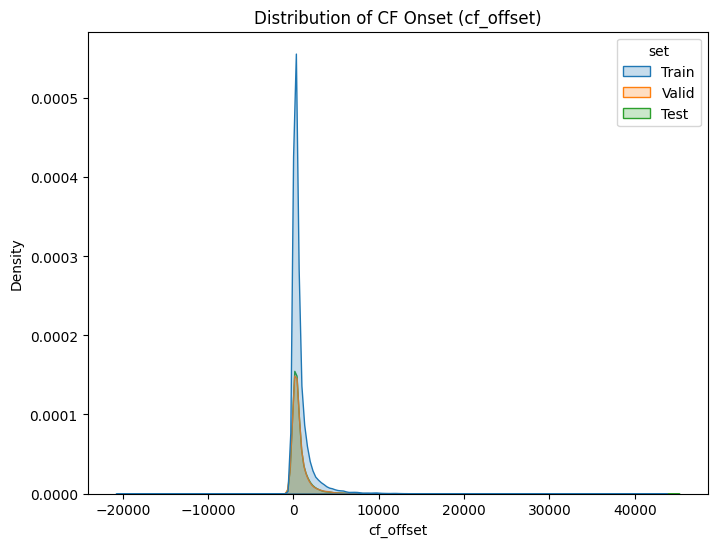

=== CF Offset Statistics Table ===
                  Train         Valid          Test
Statistic                                          
count      24127.000000   8053.000000   8058.000000
mean         818.509388    844.815969    836.475552
min       -20114.000000 -12222.000000  -6033.000000
max        43105.000000  42107.000000  44289.000000
std         1779.356495   1972.002576   1896.300893
median       291.000000    291.000000    289.000000
[CF Outcomes] 🪄 Process over at 2025-03-26 12:26:50.239990...
2025-03-26 12:26:52.033617
[MakeLoaders] Beginning job... 😤
[Binary] Detecting binary itemids ...
  found 15 binary itemids => {32, 33, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31}
[Trim] Trimming: percentile=0.01
  trimmed => train=21549652, valid=7327190, test=7162543
  [train] hadm_id row count => mean=893.18, std=1182.01, min=27, max=25582, median=492.0
  [valid] hadm_id row count => mean=909.87, std=1175.19, min=71, max=18978, median=500.0
  [test] hadm_id row count => m

In [3]:
mimic_static = pd.read_feather('mimic_data_static.feather')
mimic_outcome, mimic_ids = process_static(mimic_static)

data_vital = pd.read_feather('mimic_data_vital.feather').rename(columns={'valuenum' : 'value'}).drop_duplicates()
data_lab = pd.read_feather('mimic_data_lab.feather').rename(columns={'valuenum' : 'value'}).drop_duplicates()
data_treatment = pd.read_feather('mimic_data_treatment.feather').rename(columns={'valuenum' : 'value'}).drop_duplicates()

data = pd.concat([
    data_vital, 
    data_lab, 
    data_treatment
    ])

# 저장
with open('item_dict_total.pkl', 'rb') as f:
    item_dict_total = pickle.load(f)

# (1) clip_bounds
with open('clip_bounds_24_mimic.pkl', 'rb') as f:
    clip_bounds_all = pickle.load(f)

# (2) scaler_dict
with open('scaler_dict_24_mimic.pkl', 'rb') as f:
    scaler_dict_all = pickle.load(f)

# item_dict_total을 사용하여 원래의 itemid 값을 매핑합니다.
# item_dict_total의 key는 원래의 itemid 값, value는 매핑된 코드라고 가정합니다.
data['itemid'] = data['itemid'].map(item_dict_total)

# 만약 필요하다면 숫자형으로 변환 (오류 발생 시 NaN 처리)
data['itemid'] = pd.to_numeric(data['itemid'], errors='coerce')

# 'value'에 결측치가 있는 행 제거
data = data.dropna(subset=['value'])
data_stats = calculate_all_stats(data)

emb_idx_total = len(item_dict_total)

# 재현성 유지를 위해 seed를 고정하고 섞습니다.
np.random.seed(9871)
np.random.shuffle(mimic_ids)

# 예: 80%를 train, 나머지를 valid로 사용
train_size = int(len(mimic_ids) * 0.6)
valid_size = int(len(mimic_ids) * 0.8)
train_hadm_ids = mimic_ids[:train_size]
valid_hadm_ids = mimic_ids[train_size:valid_size]
test_hadm_ids = mimic_ids[valid_size:]

train_final_ids = train_hadm_ids
valid_final_ids = valid_hadm_ids
test_final_ids = test_hadm_ids

map_itemids = item_dict_total['map']
lactate_itemids = item_dict_total['lactate']
c01_itemids = item_dict_total['c01']



# (D) 최종 DF - CF가 있는 stay만 or 전체 stay


train_df = data[data['hadm_id'].isin(train_final_ids)].copy().reset_index(drop=True)
valid_df = data[data['hadm_id'].isin(valid_final_ids)].copy().reset_index(drop=True)
test_df = data[data['hadm_id'].isin(test_final_ids)].copy().reset_index(drop=True)

train_outcome_df, valid_outcome_df, test_outcome_df = build_cf_outcome(train_df, valid_df, test_df, map_itemids, lactate_itemids, c01_itemids)

#--------------------------
# Only stays with CF
#--------------------------
train_outcome_df = train_outcome_df.dropna().reset_index(drop=True)
valid_outcome_df = valid_outcome_df.dropna().reset_index(drop=True)
test_outcome_df = test_outcome_df.dropna().reset_index(drop=True)

# train_outcome_df.to_feather('./model_results/train_cf_outcome.feather')
# valid_outcome_df.to_feather('./model_results/valid_cf_outcome.feather')
# test_outcome_df.to_feather('./model_results/test_cf_outcome.feather')

train_final_ids = train_outcome_df['hadm_id'].unique()
valid_final_ids = valid_outcome_df['hadm_id'].unique()
test_final_ids = test_outcome_df['hadm_id'].unique()


#--------------------------
#--------------------------

train_df = data[data['hadm_id'].isin(train_final_ids)].copy().reset_index(drop=True)
valid_df = data[data['hadm_id'].isin(valid_final_ids)].copy().reset_index(drop=True)
test_df = data[data['hadm_id'].isin(test_final_ids)].copy().reset_index(drop=True)
#--------------------------
#--------------------------

print(datetime.datetime.now())

loader_maker = strats.MakeLoadersCF(train_df, valid_df, test_df,
                        train_outcome_df, valid_outcome_df, test_outcome_df,
                        obs_window=24*60, batch_size=64, mask_length=6*60,
                        mask_segment_count=4, trim_percentile=0.01, scale=True, step=2*60, emb_idx=emb_idx_total, upsample=True)



scaler_dict, clip_bounds, train_loader, valid_loader, test_loader, emb_idx = loader_maker.run_all(clip_bounds=clip_bounds_all, scalers_dict=scaler_dict_all)


print(datetime.datetime.now())

In [4]:
data = data_vital

data['itemid'] = data['itemid'].map(item_dict_total)

# 만약 필요하다면 숫자형으로 변환 (오류 발생 시 NaN 처리)
data['itemid'] = pd.to_numeric(data['itemid'], errors='coerce')

# 'value'에 결측치가 있는 행 제거
data = data.dropna(subset=['value'])
data_stats = calculate_all_stats(data)

train_df = data[data['hadm_id'].isin(train_final_ids)].copy().reset_index(drop=True)
valid_df = data[data['hadm_id'].isin(valid_final_ids)].copy().reset_index(drop=True)
test_df = data[data['hadm_id'].isin(test_final_ids)].copy().reset_index(drop=True)


loader_maker = strats.MakeLoadersCF(train_df, valid_df, test_df,
                        train_outcome_df, valid_outcome_df, test_outcome_df,
                        obs_window=24*60, batch_size=64, mask_length=6*60,
                        mask_segment_count=4, trim_percentile=0.01, scale=True, step=2*60, min_window=1, emb_idx=emb_idx_total)

scaler_vital_dict, clip_vital_bounds, train_vital_loader, valid_vital_loader, test_vital_loader, emb_vital_idx = loader_maker.run_all(clip_bounds=clip_bounds_all, scalers_dict=scaler_dict_all)



print(datetime.datetime.now())

print('[Finished] Vital samples created')

[MakeLoaders] Beginning job... 😤
[Binary] Detecting binary itemids ...
  found 0 binary itemids => set()
[Trim] Trimming: percentile=0.01
  trimmed => train=11335989, valid=3849230, test=3776258
  [train] hadm_id row count => mean=469.85, std=613.93, min=19, max=14669, median=262.0
  [valid] hadm_id row count => mean=477.99, std=607.74, min=29, max=8805, median=268.0
  [test] hadm_id row count => mean=468.63, std=617.67, min=44, max=12293, median=259.0
[Scale] Scaling type : StandardScaler
  Scaling done.
[MakeLoadersCF] Creating circulatory failure datasets ...
[TimeSeriesDatasetCF_Outcome] Total 21787 stays used
=== Stay-wise Statistics Table ===
                    Stay
Statistic               
count       21787.000000
mean         7917.204893
min          1681.000000
max        229832.000000
std          9877.248059
median       4494.000000
[TimeSeriesDatasetCF_Outcome] Created 65489 samples. CF=1: 11807
[TimeSeriesDatasetCF_Outcome] Sequence length stats: mean=88.36, std=18.09, mi

In [5]:
data = data_lab

data['itemid'] = data['itemid'].map(item_dict_total)

# 만약 필요하다면 숫자형으로 변환 (오류 발생 시 NaN 처리)
data['itemid'] = pd.to_numeric(data['itemid'], errors='coerce')

# 'value'에 결측치가 있는 행 제거
data = data.dropna(subset=['value'])
data_stats = calculate_all_stats(data)

train_df = data[data['hadm_id'].isin(train_final_ids)].copy().reset_index(drop=True)
valid_df = data[data['hadm_id'].isin(valid_final_ids)].copy().reset_index(drop=True)
test_df = data[data['hadm_id'].isin(test_final_ids)].copy().reset_index(drop=True)

loader_maker = strats.MakeLoadersCF(train_df, valid_df, test_df,
                        train_outcome_df, valid_outcome_df, test_outcome_df,
                        obs_window=24*60, batch_size=64, mask_length=6*60,
                        mask_segment_count=4, trim_percentile=0.01, scale=True, step=2*60, min_window=1, emb_idx=emb_idx_total)

scaler_lab_dict, clip_lab_bounds, train_lab_loader, valid_lab_loader, test_lab_loader, emb_lab_idx = loader_maker.run_all(scalers_dict=scaler_dict_all, clip_bounds=clip_bounds_all)


print(datetime.datetime.now())
print('[Finished] Lab samples created')

[MakeLoaders] Beginning job... 😤
[Binary] Detecting binary itemids ...
  found 0 binary itemids => set()
[Trim] Trimming: percentile=0.01
  trimmed => train=4454492, valid=1500640, test=1473328
  [train] hadm_id row count => mean=184.63, std=237.94, min=1, max=5158, median=107.0
  [valid] hadm_id row count => mean=186.35, std=228.48, min=4, max=2977, median=109.0
  [test] hadm_id row count => mean=182.84, std=246.86, min=4, max=8176, median=108.0
[Scale] Scaling type : StandardScaler
  Scaling done.
[MakeLoadersCF] Creating circulatory failure datasets ...
[TimeSeriesDatasetCF_Outcome] Total 21333 stays used
=== Stay-wise Statistics Table ===
                    Stay
Statistic               
count       21333.000000
mean         7935.031360
min          1681.000000
max        229471.000000
std          9926.759677
median       4491.000000
[TimeSeriesDatasetCF_Outcome] Created 65865 samples. CF=1: 11499
[TimeSeriesDatasetCF_Outcome] Sequence length stats: mean=29.26, std=14.52, min=1, m

In [6]:
data = data_treatment

data['itemid'] = data['itemid'].map(item_dict_total)

# 만약 필요하다면 숫자형으로 변환 (오류 발생 시 NaN 처리)
data['itemid'] = pd.to_numeric(data['itemid'], errors='coerce')

# 'value'에 결측치가 있는 행 제거
data = data.dropna(subset=['value'])
data_stats = calculate_all_stats(data)

train_df = data[data['hadm_id'].isin(train_final_ids)].copy().reset_index(drop=True)
valid_df = data[data['hadm_id'].isin(valid_final_ids)].copy().reset_index(drop=True)
test_df = data[data['hadm_id'].isin(test_final_ids)].copy().reset_index(drop=True)
print(datetime.datetime.now())

loader_maker = strats.MakeLoadersCF(train_df, valid_df, test_df,
                        train_outcome_df, valid_outcome_df, test_outcome_df,
                        obs_window=24*60, batch_size=64, mask_length=6*60,
                        mask_segment_count=4, trim_percentile=0.01, scale=True, step=2*60, min_window=1, emb_idx=emb_idx_total)

scaler_treatment_dict, clip_treatment_bounds, train_treatment_loader, valid_treatment_loader, test_treatment_loader, emb_treatment_idx = loader_maker.run_all(scalers_dict=scaler_dict_all,
                                                                                                                                                              clip_bounds=clip_bounds_all)

print(datetime.datetime.now())
print('[Finished] Treatment samples created')

2025-03-26 12:53:17.190750
[MakeLoaders] Beginning job... 😤
[Binary] Detecting binary itemids ...
  found 15 binary itemids => {32, 33, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31}
[Trim] Trimming: percentile=0.01
  trimmed => train=5759171, valid=1977320, test=1912957
  [train] hadm_id row count => mean=245.35, std=391.65, min=1, max=7434, median=124.0
  [valid] hadm_id row count => mean=252.37, std=401.33, min=1, max=8075, median=128.0
  [test] hadm_id row count => mean=244.34, std=390.36, min=1, max=6647, median=124.0
[Scale] Scaling type : StandardScaler
  Scaling done.
[MakeLoadersCF] Creating circulatory failure datasets ...
[TimeSeriesDatasetCF_Outcome] Total 20889 stays used
=== Stay-wise Statistics Table ===
                    Stay
Statistic               
count       20889.000000
mean         7909.894634
min          1681.000000
max        229918.000000
std          9801.013856
median       4487.000000
[TimeSeriesDatasetCF_Outcome] Created 60364 samples. CF=1: 10732
[

# Experiments

### Define class

In [7]:
class STraTSExperiment:
    """
    STraTS 모델 전체 파이프라인을 하나의 클래스로 묶어,
    - 모델 파라미터 설정
    - Pretrain
    - Pretrain Validate
    - Downstream Train
    - Evaluate
    등을 메서드로 구성.
    """
    def __init__(self,
                 emb_idx,
                 train_loader,
                 valid_loader,
                 test_loader,
                 version=None,
                 # 모델 관련 파라미터
                 num_heads=4,
                 num_layers=2,
                 ff_dim=64,
                 embed_dim=32,
                 dropout=0.2,
                 time_activation='relu',
                 value_activation='tanh',
                 final_emb_type='cls',
                 fusion_emb_weight=0.5,
                 final_emb_weight=0.5,
                 loss_type='bce',
                 # 학습 관련 파라미터
                 patience=30,
                 device=None):
        """
        emb_idx: 최종 임베딩 개수 (num_features)
        version: 모델/결과 파일 저장에 쓸 버전 이름 (기본값: 날짜_0 형태)
        기타 모델 하이퍼파라미터들...
        """
        # 버전 설정
        if version is None:
            # 날짜_0 형태 기본
            ver = 0
            today = datetime.date.today().isoformat()  # 예: '2024-01-05'
            version = f'{today}_{ver}'
        self.version = version
        self.train_loader = train_loader
        self.valid_loader = valid_loader
        self.test_loader = test_loader

        # device
        if device is None:
            device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.device = device

        # 모델 생성
        self.model = strats.STraTSModel(
            num_features=emb_idx,
            embed_dim=embed_dim,
            num_heads=num_heads,
            num_blocks=num_layers,
            ff_dim=ff_dim,
            dropout=dropout,
            time_activation=time_activation,
            value_activation=value_activation,
            final_emb_type=final_emb_type,
            fusion_emb_weight=fusion_emb_weight,
            final_emb_weight=final_emb_weight,
            loss_type=loss_type
        ).to(self.device)

        # 학습 관련 파라미터
        self.patience = patience

        # optimizer (사용자가 바꿀 수 있도록)

        print(f"[STraTSExperiment] Initialized with version={self.version}, device={self.device}.")

    def pretrain(self, epochs=1000,
                 model_save_dir='./models_pt', learning_rate=1e-3):
        """
        Pretrain the model (masking-based).
        """
        # ensure save dir
        os.makedirs(model_save_dir, exist_ok=True)

        # pretrain
        print("[STraTSExperiment] Starting pretrain...")
        save_path = os.path.join(model_save_dir, f'pretrained_model_{self.version}.pt')

        optimizer = torch.optim.AdamW(self.model.parameters(), lr=learning_rate)

        strats.pretrain_model(model=self.model,
                              train_loader=self.train_loader,
                              valid_loader=self.valid_loader,
                              epochs=epochs,
                              optimizer=optimizer,
                              device=self.device,
                              patience=self.patience,
                              model_save_path=save_path)

        print("[STraTSExperiment] Pretrain finished.")
        print(f"[STraTSExperiment] Best pretrain model saved at: {save_path}")
        self.model.load_state_dict(torch.load(save_path)) # Load best pretrain model

    def validate_pretrain(self, result_save_dir='./model_results'):
        """
        Validate pretrain results -> CSV
        """
        os.makedirs(result_save_dir, exist_ok=True)
        # 로드된 self.model 이용
        df_pretrain_results = strats.validate_model(self.model, self.valid_loader, device=self.device)
        # emb_idx에 해당하는 패딩/불필요 row 제거
        df_pretrain_results = df_pretrain_results.loc[df_pretrain_results['Variable'] != emb_idx]
        # CSV 저장
        save_path = os.path.join(result_save_dir, f'pretrained_result_{self.version}.csv')
        df_pretrain_results.to_csv(save_path, index=False)
        print(f"[STraTSExperiment] Pretrain validation result saved to {save_path}")

    def load_pretrained_model(self, model_load_path):
        """
        명시적으로 pretrained 모델을 로드하고 싶다면 호출
        """
        self.model.load_state_dict(torch.load(model_load_path, map_location=self.device))
        print(f"[STraTSExperiment] Loaded pretrained model from {model_load_path}")

    def train_downstream(self,
                         epochs=1000,
                         freeze=False,
                         model_save_dir='./models_pt',
                         result_save_dir='./model_results',
                         learning_rate = 1e-4):
        """
        Downstream train (fine-tuning or freeze)
        - freeze=True => pretrain 부분 고정
        - use_loss => ['death'], ['saps', 'sofa', 'death'] 등
        """
        os.makedirs(model_save_dir, exist_ok=True)
        os.makedirs(result_save_dir, exist_ok=True)
        save_path = os.path.join(model_save_dir, f'downstream_model_{self.version}.pt')

        optimizer = torch.optim.AdamW(self.model.parameters(), lr=learning_rate)


        print("[STraTSExperiment] Starting downstream training...")
        df_downstream_loss = strats.train_model(
            model=self.model,
            train_loader=self.train_loader,
            valid_loader=self.valid_loader,
            epochs=epochs,
            optimizer=optimizer,
            device=self.device,
            patience=self.patience,
            freeze=freeze,
            model_save_path=save_path,
        )
        # CSV로 저장
        csv_path = os.path.join(result_save_dir, f'downstream_loss_{self.version}.csv')
        df_downstream_loss.to_csv(csv_path, index=False)
        print("[STraTSExperiment] Downstream training finished.")
        print(f"[STraTSExperiment] Best downstream model saved at: {save_path}")
        print(f"[STraTSExperiment] Training loss saved to {csv_path}")
        self.model.load_state_dict(torch.load(save_path))

    def load_downstream_model(self, model_load_path):
        """
        명시적으로 downstream 모델 로드
        """
        self.model.load_state_dict(torch.load(model_load_path, map_location=self.device))
        print(f"[STraTSExperiment] Loaded downstream model from {model_load_path}")

    def evaluate(self, result_save_dir='./model_results'):
        """
        Evaluate the final model on test set => metrics (AUROC, AUPRC, etc.)
        Also save the (hadm_id, query_time, embedding) data to CSV.
        """
        os.makedirs(result_save_dir, exist_ok=True)

        # 이 evaluate_model 함수는 수정된 버전으로,
        # (metrics, test_embeddings)를 리턴한다고 가정
        metrics, test_embeddings = strats.evaluate_model(self.model, self.test_loader, self.device)

        # 1) 성능 지표 출력
        print("[STraTSExperiment] Test Metrics:")
        for k, v in metrics.items():
            print(f"  {k}: {v:.4f}")

        with open(f'{result_save_dir}/test_metrics_{self.version}.csv','w') as f:
            w = csv.writer(f)
            w.writerow(metrics.keys())
            w.writerow(metrics.values())

        # 2) 임베딩 저장
        # test_embeddings = {
        #   'hadm_id': np.array([...]),        # shape (N,)
        #   'query_time': np.array([...]),     # shape (N,)
        #   'embedding': np.array([...])       # shape (N, embed_dim)
        # }
        hadm_ids = test_embeddings['hadm_id']
        query_times = test_embeddings['query_time']
        emb_array = test_embeddings['embedding']  # shape=(N, embed_dim)
        num_samples, embed_dim = emb_array.shape

        # 임베딩을 pandas DataFrame으로 변환
        # 각 row: hadm_id, query_time, emb_0, emb_1, ... emb_(embed_dim-1)
        embed_df = pd.DataFrame({
            'hadm_id': hadm_ids,
            'query_time': query_times
        })
        for i in range(embed_dim):
            embed_df[f'emb_{i}'] = emb_array[:, i]

        # CSV로 저장
        emb_save_path = os.path.join(result_save_dir, f'test_embedding_{self.version}.csv')
        embed_df.to_csv(emb_save_path, index=False)


        # Train embeddings
        _, train_embedding = strats.evaluate_model(self.model, self.train_loader, self.device)

        hadm_ids = train_embedding['hadm_id']
        query_times = train_embedding['query_time']
        emb_array = train_embedding['embedding']  # shape=(N, embed_dim)
        num_samples, embed_dim = emb_array.shape

        embed_df = pd.DataFrame({
            'hadm_id': hadm_ids,
            'query_time': query_times
        })
        for i in range(embed_dim):
            embed_df[f'emb_{i}'] = emb_array[:, i]

        # CSV로 저장
        emb_save_path = os.path.join(result_save_dir, f'train_embedding_{self.version}.csv')
        embed_df.to_csv(emb_save_path, index=False)

        # Valid...
        _, valid_embedding = strats.evaluate_model(self.model, self.valid_loader, self.device)

        hadm_ids = valid_embedding['hadm_id']
        query_times = valid_embedding['query_time']
        emb_array = valid_embedding['embedding']  # shape=(N, embed_dim)
        num_samples, embed_dim = emb_array.shape

        embed_df = pd.DataFrame({
            'hadm_id': hadm_ids,
            'query_time': query_times
        })
        for i in range(embed_dim):
            embed_df[f'emb_{i}'] = emb_array[:, i]

        # CSV로 저장
        emb_save_path = os.path.join(result_save_dir, f'valid_embedding_{self.version}.csv')
        embed_df.to_csv(emb_save_path, index=False)

        print(f"[STraTSExperiment] Saved embeddings to {emb_save_path}")


        return metrics
    

### Task 0

[STraTSExperiment] Initialized with version=mimic_24_fusion_cf8_2hr_upsampled, device=cuda.
[STraTSExperiment] Loaded pretrained model from ./models_pt/pretrained_model_mimic_24h.pt
[STraTSExperiment] Starting pretrain...


[Pretrain] Epoch [1/50] - Training:   0%|          | 0/1696 [00:00<?, ?it/s]

[Pretrain] Epoch [1/50] - Validation:   0%|          | 0/370 [00:00<?, ?it/s]

[Pretrain] Epoch 1: Train Loss = 0.3600, Valid Loss = 0.3492


[Pretrain] Epoch [2/50] - Training:   0%|          | 0/1696 [00:00<?, ?it/s]

...

[Pretrain] Epoch [45/50] - Validation:   0%|          | 0/370 [00:00<?, ?it/s]

[Pretrain] Epoch 45: Train Loss = 0.3550, Valid Loss = 0.3531


[Pretrain] Epoch [46/50] - Training:   0%|          | 0/1696 [00:00<?, ?it/s]

[Pretrain] Epoch [46/50] - Validation:   0%|          | 0/370 [00:00<?, ?it/s]

[Pretrain] Epoch 46: Train Loss = 0.3550, Valid Loss = 0.3498
Early stopping triggered (pretrain).


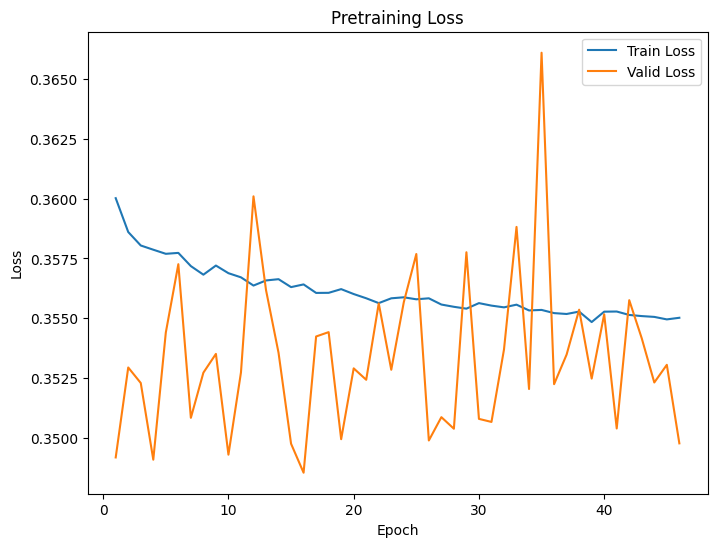

[STraTSExperiment] Pretrain finished.
[STraTSExperiment] Best pretrain model saved at: ./models_pt\pretrained_model_mimic_24_fusion_cf8_2hr_upsampled.pt


In [8]:
# CLS final_emb
exp_0 = STraTSExperiment(
    emb_idx=emb_idx,            # num_features
    train_loader=train_loader,
    valid_loader=valid_loader,
    test_loader=test_loader,
    version='mimic_24_fusion_cf8_2hr_upsampled',
    num_heads=4,
    num_layers=2,
    ff_dim=64,
    embed_dim=32,
    dropout=0.2,
    time_activation='relu',
    value_activation='tanh',
    final_emb_type='fusion',
    fusion_emb_weight=0.5,
    final_emb_weight=0.5,
    patience=30,
    loss_type='bce'
)

exp_0.load_pretrained_model('./models_pt/pretrained_model_mimic_24h.pt')

# 1) Pretrain
exp_0.pretrain(epochs=50, learning_rate=1e-3)

[STraTSExperiment] Pretrain validation result saved to ./model_results\pretrained_result_mimic_24_fusion_cf8_2hr_upsampled.csv
[STraTSExperiment] Starting downstream training...


[Downstream] Epoch [1/1000] - Training:   0%|          | 0/1696 [00:00<?, ?it/s]

[Downstream] Epoch [1/1000] - Validation:   0%|          | 0/370 [00:00<?, ?it/s]

[Epoch 1] Train Loss=0.6405, Valid Loss=0.5862, Valid AUROC=0.7416, AUPRC=0.3455


[Downstream] Epoch [2/1000] - Training:   0%|          | 0/1696 [00:00<?, ?it/s]

...

[Downstream] Epoch [33/1000] - Validation:   0%|          | 0/370 [00:00<?, ?it/s]

[Epoch 33] Train Loss=0.5499, Valid Loss=0.6319, Valid AUROC=0.7156, AUPRC=0.3334


[Downstream] Epoch [34/1000] - Training:   0%|          | 0/1696 [00:00<?, ?it/s]

[Downstream] Epoch [34/1000] - Validation:   0%|          | 0/370 [00:00<?, ?it/s]

[Epoch 34] Train Loss=0.5478, Valid Loss=0.6134, Valid AUROC=0.7173, AUPRC=0.3350
Early stopping triggered (downstream).


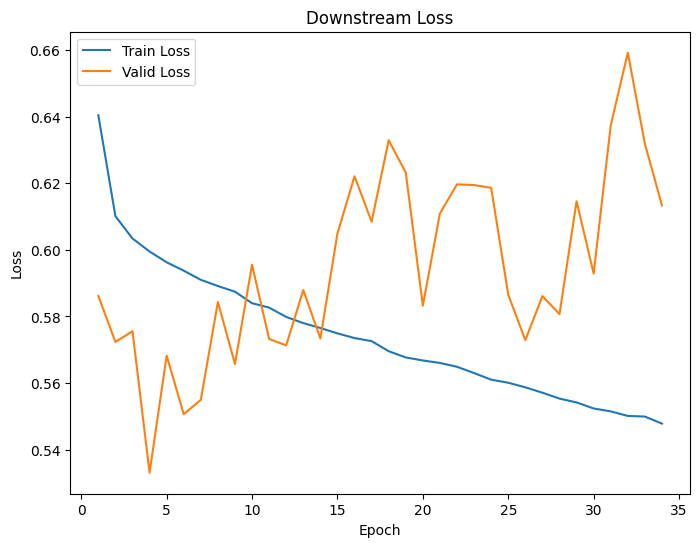

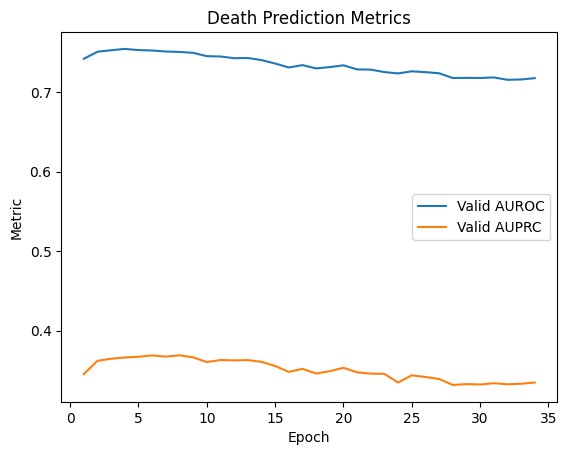

[STraTSExperiment] Downstream training finished.
[STraTSExperiment] Best downstream model saved at: ./models_pt\downstream_model_mimic_24_fusion_cf8_2hr_upsampled.pt
[STraTSExperiment] Training loss saved to ./model_results\downstream_loss_mimic_24_fusion_cf8_2hr_upsampled.csv


[Evaluating on dataset]:   0%|          | 0/358 [00:00<?, ?it/s]

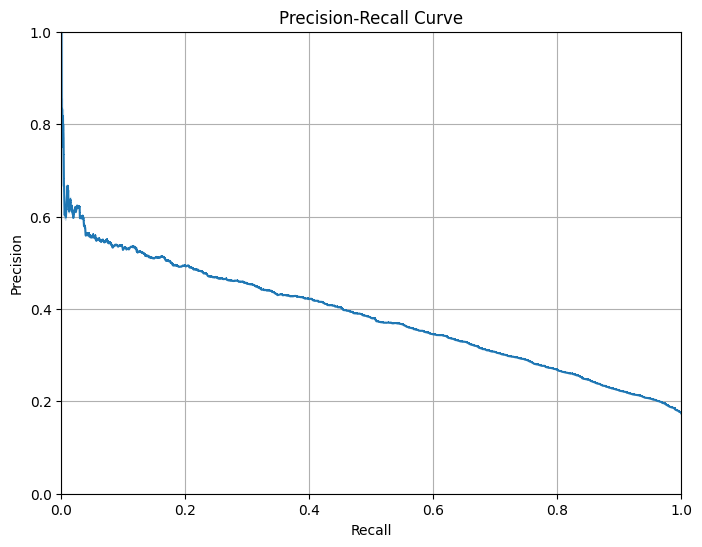

[STraTSExperiment] Test Metrics:
  AUROC: 0.7457
  AUPRC: 0.3831
  Precision: 0.3363
  Recall: 0.6281
  F1: 0.4380
  Accuracy: 0.7210
  Brier: 0.1843
  Precision@Recall_0.8: 0.2679


[Evaluating on dataset]:   0%|          | 0/1696 [00:00<?, ?it/s]

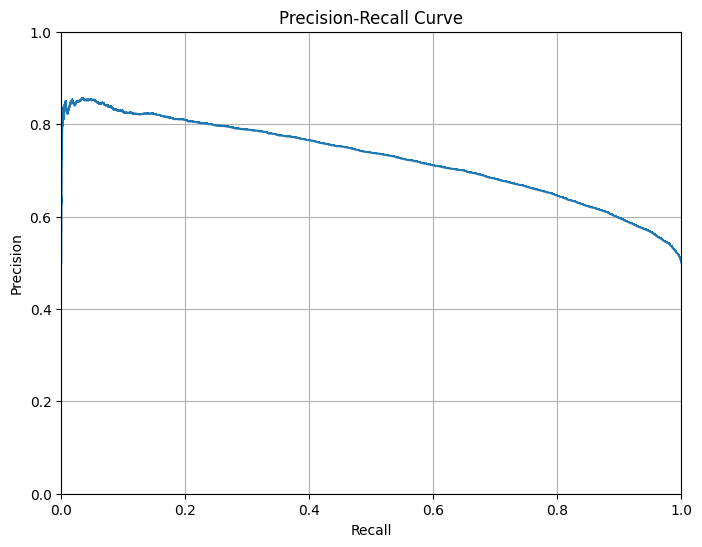

[Evaluating on dataset]:   0%|          | 0/370 [00:00<?, ?it/s]

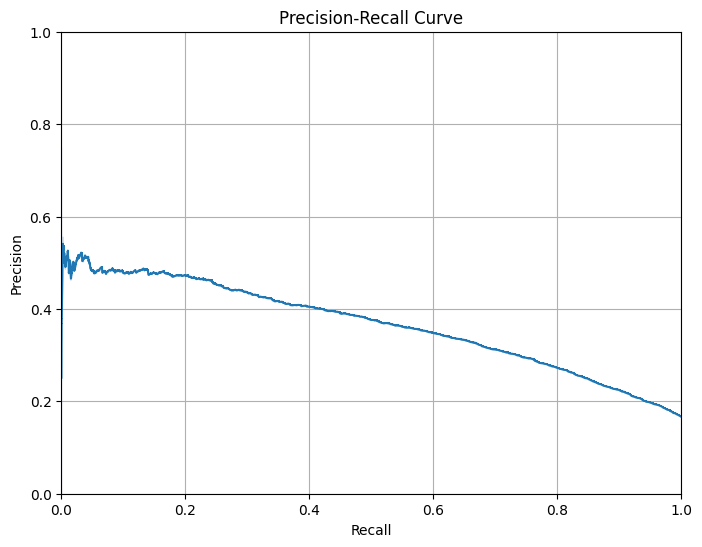

[STraTSExperiment] Saved embeddings to ./model_results\valid_embedding_mimic_24_fusion_cf8_2hr_upsampled.csv


In [9]:
# 2) Validate pretrain
exp_0.validate_pretrain()

# 3) Downstream train
exp_0.train_downstream(epochs=1000,
                            freeze=False,
                            learning_rate=1e-4)

# 4) Evaluate
metrics_0 = exp_0.evaluate()

### Task 1

[STraTSExperiment] Initialized with version=mimic_vital_24_fusion_cf8_2hr_upsampled, device=cuda.
[STraTSExperiment] Loaded downstream model from ./models_pt/downstream_model_mimic_24_fusion_cf8_2hr_upsampled.pt


[Evaluating on dataset]:   0%|          | 0/353 [00:00<?, ?it/s]

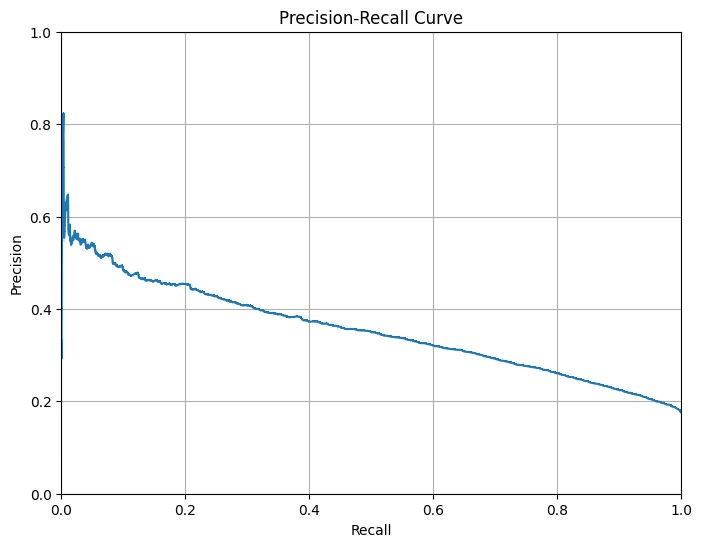

[STraTSExperiment] Test Metrics:
  AUROC: 0.7282
  AUPRC: 0.3547
  Precision: 0.2947
  Recall: 0.6922
  F1: 0.4134
  Accuracy: 0.6565
  Brier: 0.2157
  Precision@Recall_0.8: 0.2606


[Evaluating on dataset]:   0%|          | 0/1024 [00:00<?, ?it/s]

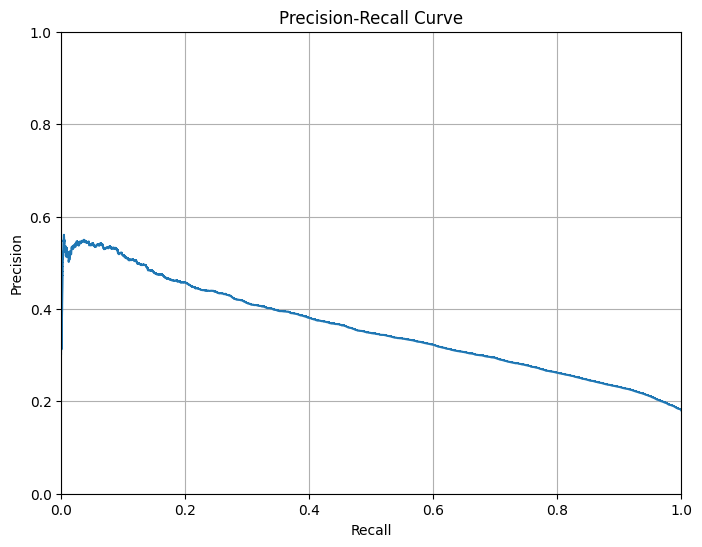

[Evaluating on dataset]:   0%|          | 0/367 [00:00<?, ?it/s]

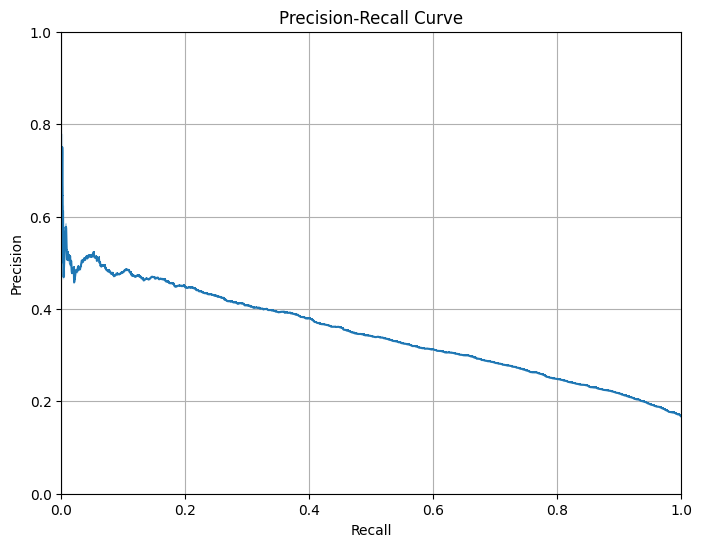

[STraTSExperiment] Saved embeddings to ./model_results\valid_embedding_mimic_vital_24_fusion_cf8_2hr_upsampled.csv


In [10]:
# Fusion final_emb
exp_1 = STraTSExperiment(
    emb_idx=emb_idx,            # num_features
    train_loader=train_vital_loader,
    valid_loader=valid_vital_loader,
    test_loader=test_vital_loader,
    version='mimic_vital_24_fusion_cf8_2hr_upsampled',           # None이면 자동으로 날짜_0 형태
    num_heads=4,
    num_layers=2,
    ff_dim=64,
    embed_dim=32,
    dropout=0.2,
    time_activation='relu',
    value_activation='tanh',
    final_emb_type='fusion',
    fusion_emb_weight=0.5,
    final_emb_weight=0.5,
    patience=30,
    loss_type='bce'
)
exp_1.load_downstream_model('./models_pt/downstream_model_mimic_24_fusion_cf8_2hr_upsampled.pt')

# Evaluate
metrics_1 = exp_1.evaluate()


### Task 2

[STraTSExperiment] Initialized with version=mimic_lab_24_fusion_cf8_2hr_upsampled, device=cuda.
[STraTSExperiment] Loaded downstream model from ./models_pt/downstream_model_mimic_24_fusion_cf8_2hr_upsampled.pt


[Evaluating on dataset]:   0%|          | 0/357 [00:00<?, ?it/s]

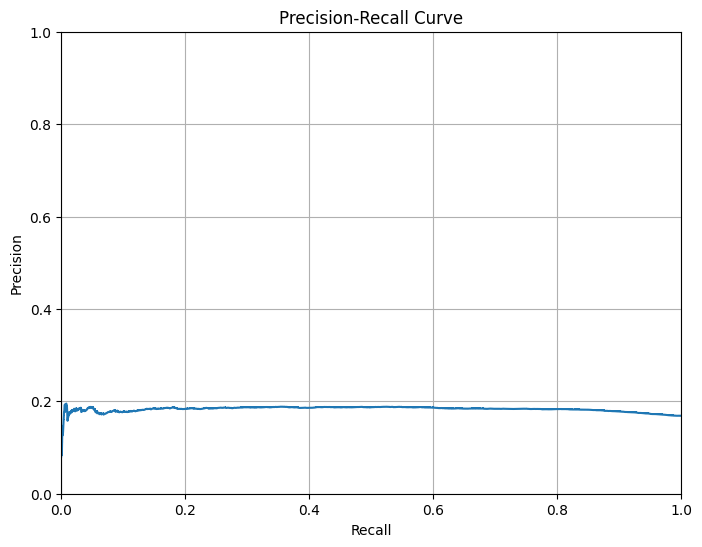

[STraTSExperiment] Test Metrics:
  AUROC: 0.5441
  AUPRC: 0.1831
  Precision: 0.1852
  Recall: 0.2484
  F1: 0.2122
  Accuracy: 0.6886
  Brier: 0.1979
  Precision@Recall_0.8: 0.1834


[Evaluating on dataset]:   0%|          | 0/1030 [00:00<?, ?it/s]

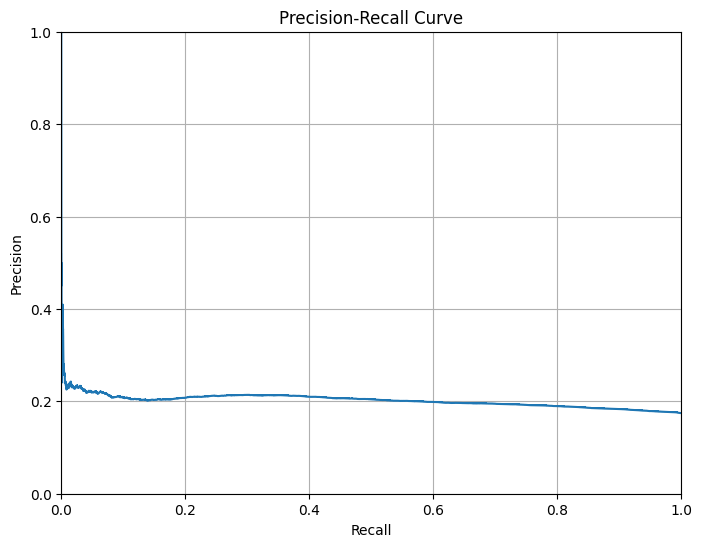

[Evaluating on dataset]:   0%|          | 0/369 [00:00<?, ?it/s]

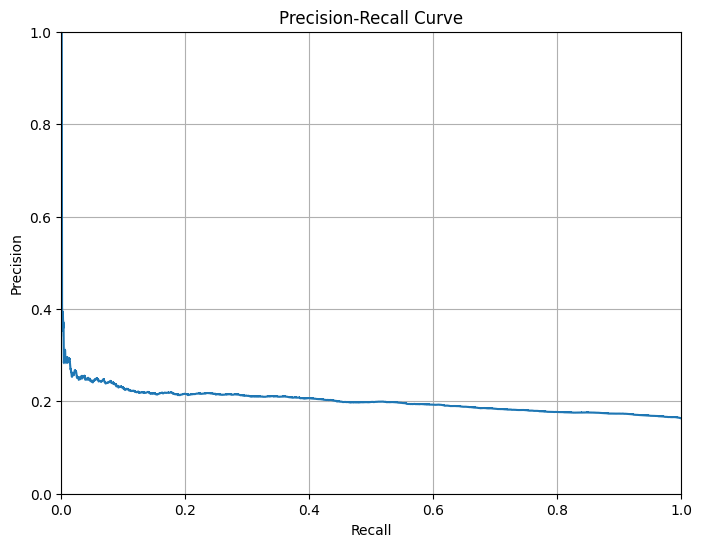

[STraTSExperiment] Saved embeddings to ./model_results\valid_embedding_mimic_lab_24_fusion_cf8_2hr_upsampled.csv


{'AUROC': 0.5440568392058074,
 'AUPRC': 0.18305730742627196,
 'Precision': 0.18519953506392872,
 'Recall': 0.24844074844074845,
 'F1': 0.21220865704772476,
 'Accuracy': 0.6886159245448563,
 'Brier': 0.197863515819664,
 'Precision@Recall_0.8': 0.183414115143634}

In [11]:
# Lab
exp_2 = STraTSExperiment(
    emb_idx=emb_idx,            # num_features
    train_loader=train_lab_loader,
    valid_loader=valid_lab_loader,
    test_loader=test_lab_loader,
    version='mimic_lab_24_fusion_cf8_2hr_upsampled',
    num_heads=4,
    num_layers=2,
    ff_dim=64,
    embed_dim=32,
    dropout=0.2,
    time_activation='relu',
    value_activation='tanh',
    final_emb_type='fusion',
    fusion_emb_weight=0.5,
    final_emb_weight=0.5,
    patience=30,
    loss_type='bce'
)
exp_2.load_downstream_model('./models_pt/downstream_model_mimic_24_fusion_cf8_2hr_upsampled.pt')

# 1) Pretrain
exp_2.evaluate()

### Task 3

[STraTSExperiment] Initialized with version=mimic_treatment_24_fusion_cf8_2hr_upsampled, device=cuda.
[STraTSExperiment] Loaded downstream model from ./models_pt/downstream_model_mimic_24_fusion_cf8_2hr_upsampled.pt


[Evaluating on dataset]:   0%|          | 0/325 [00:00<?, ?it/s]

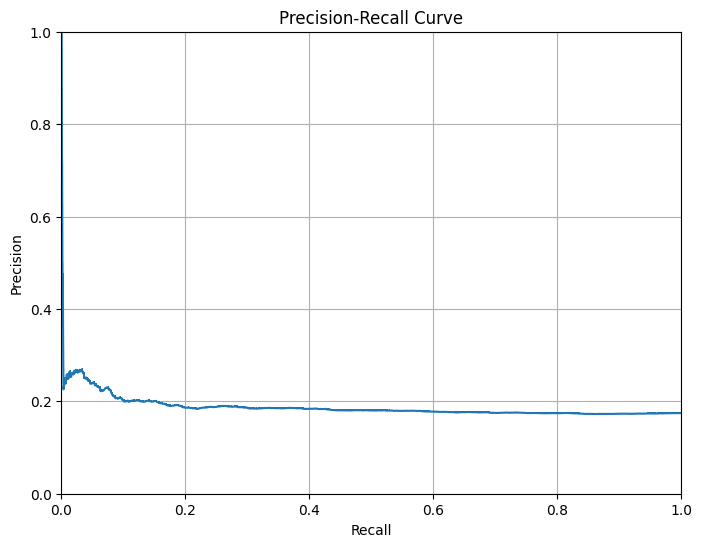

[STraTSExperiment] Test Metrics:
  AUROC: 0.5113
  AUPRC: 0.1881
  Precision: 0.2336
  Recall: 0.0568
  F1: 0.0914
  Accuracy: 0.8028
  Brier: 0.1956
  Precision@Recall_0.8: 0.1749


[Evaluating on dataset]:   0%|          | 0/944 [00:00<?, ?it/s]

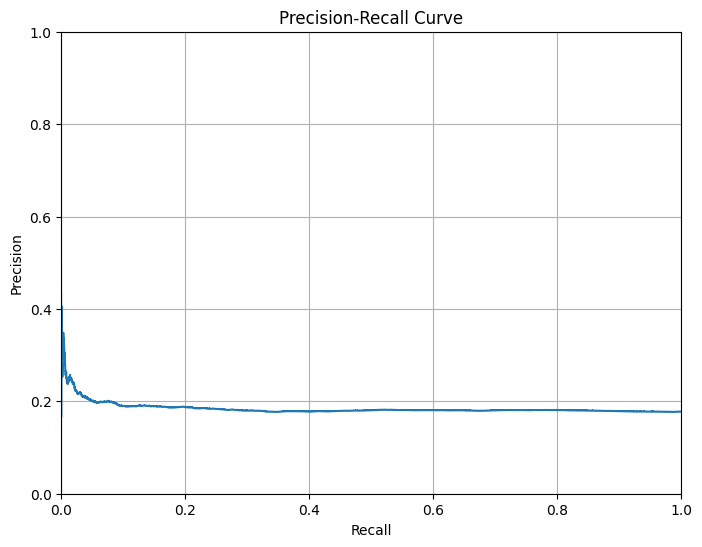

[Evaluating on dataset]:   0%|          | 0/335 [00:00<?, ?it/s]

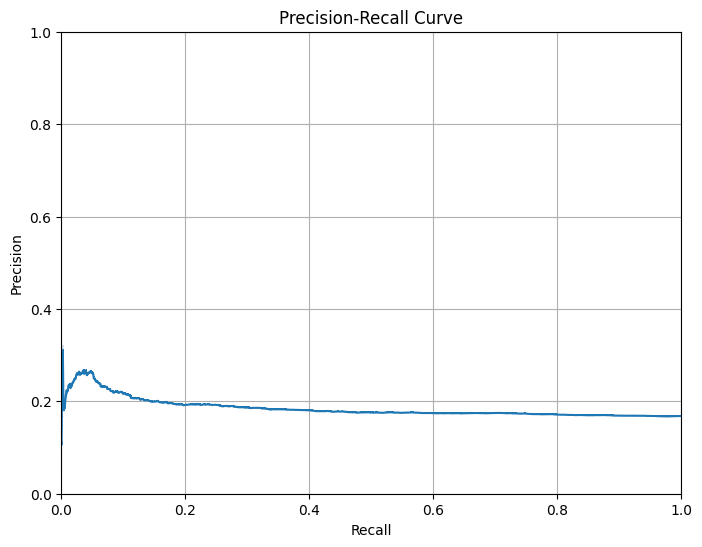

[STraTSExperiment] Saved embeddings to ./model_results\valid_embedding_mimic_treatment_24_fusion_cf8_2hr_upsampled.csv


{'AUROC': 0.5112683440176647,
 'AUPRC': 0.18808924903852905,
 'Precision': 0.23356009070294784,
 'Recall': 0.056780595369349506,
 'F1': 0.09135254988913526,
 'Accuracy': 0.8027816545550797,
 'Brier': 0.1956433557258725,
 'Precision@Recall_0.8': 0.17490223960184856}

In [12]:
# No pretraining, cls

exp_3 = STraTSExperiment(
    emb_idx=emb_idx,            # num_features
    train_loader=train_treatment_loader,
    valid_loader=valid_treatment_loader,
    test_loader=test_treatment_loader,
    version='mimic_treatment_24_fusion_cf8_2hr_upsampled',           # None이면 자동으로 날짜_0 형태
    num_heads=4,
    num_layers=2,
    ff_dim=64,
    embed_dim=32,
    dropout=0.2,
    time_activation='relu',
    value_activation='tanh',
    final_emb_type='fusion',
    fusion_emb_weight=0.5,
    final_emb_weight=0.5,
    patience=30,
    loss_type='bce'
)
exp_3.load_downstream_model('./models_pt/downstream_model_mimic_24_fusion_cf8_2hr_upsampled.pt')


# Evaluate
exp_3.evaluate()